# Outbound path length and inbound path deviation

Plot selected outbound/inbound paths and compare **outbound path length** with **mean inbound path deviation** for each trial. Outbound length is the provisional complexity measure.

Load recordings, select trials, then run the measurement and plotting calls. Each recording uses its own acquired clock, calibration and background image.


In [1]:
from __future__ import annotations

# ===============================================================================
# 1 | Locate This Checkout and Refresh Project Imports After Source Changes
# ===============================================================================

from pathlib import Path
from runpy import run_path

# --- 1.1 | Locate src/ from the checkout root or any notebook subdirectory -------
# source_root = next((
#     candidate
#     for parent in (Path.cwd(), *Path.cwd().parents)
#     for candidate in (parent, parent / "src")
#     if (candidate / "data_conduit").is_dir() and (candidate / "movement_figures").is_dir()
# ), None)
# if source_root is None:
#     raise FileNotFoundError("Open this notebook inside the data-conduit checkout.")

# # --- 1.2 | Refresh cached project modules before importing the refactored API ----
# # Load the bootstrap by file path: even a cached older package cannot shadow it.
# # Rerun the following cells afterwards to rebuild data and figures consistently.
# refresh_project_imports = run_path(
#     str(source_root / "movement_figures" / "notebook_setup.py")
# )["refresh_project_imports"]
# source_root = refresh_project_imports(source_root)

# --- 1.3 | Import the analysis and plotting functions from this checkout ---------

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import movement.kinematics as kin
from movement.plots import plot_centroid_trajectory
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display

from data_conduit.datastructures.slicing import slice_stream
from data_conduit.integrations.DLC.pose import pose_to_movement
from data_conduit.refactor_qc.training_filter import filter_trials, training_spec
from movement_figures.data_template.loading import build_datastructure, prepare_pose
from movement_figures.video import read_session_video_frame

################################################################################


## Choose recordings, trials and display settings

`INCLUDE_SESSIONS` and `LEVEL_SELECTORS` choose recordings. `TRIAL_INDEX_RANGE=slice(1, 8)` selects original trials 1–8 within each recording.

`TRAINING_SPEC` optionally applies the existing training rules. `EXCLUDE_LED_ON_SESSIONS=True` drops a whole recording containing an ON-labelled trial, checked before filtering. The label records ON-event presence, not continuous LED state.

For centimetres, enter measured calibrations in `PIXELS_PER_CM_BY_SESSION`, keyed by the printed recording IDs. `ARENA_RANGE` uses the chosen output unit.


In [2]:
################################################################################
# Recording, Processing and Display Settings
################################################################################

# === 1| Choose Existing Recordings and Original Trial Indices ===================

ROOT = Path("/media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training")
INCLUDE_SESSIONS = ("2026-06-21T093349Z",)                               # Add recorded folder names, or use None for all selected directories.
LEVEL_NAMES = ("mouseID", "day")                                       # ROOT / mouseID / day / recording folder.
LEVEL_SELECTORS = {}                                                   # Existing l0_selector/l1_selector filters may restrict mice or days.
TRIAL_INDEX_RANGE = slice(1, 8)                                        # Apply inclusive trial indices 1–8 separately within each recording.
TRAINING_SPEC = None                                                   # Set training_spec() to apply the existing refactor_qc training table.
EXCLUDE_LED_ON_SESSIONS = False                                        # True drops whole recordings containing any LED ON trial before filtering.

# === 2| Choose One Point and Optional Processing on Each Complete Recording =====

INDIVIDUAL = "individual_0"
TRACKING_KEYPOINT = "body"                                             # Keep one fixed point; do not switch centroids as keypoints disappear.
CONFIDENCE_THRESHOLD = 0.9                                             # Replace coordinates below this confidence with NaN before measurement.
MAX_GAP_FRAMES = None                                                  # Preserve missing coordinates unless interpolation is explicitly enabled.
SMOOTHING_WINDOW = None                                                # Preserve positions unless a median window in samples is supplied.
MAX_SAMPLE_INTERVAL_S = None                                           # Supply an acquisition-based threshold to reject time gaps as well as NaNs.

# === 3| Set Per-Recording Calibration and Explicit Plot Appearance ==============

SPATIAL_UNIT = "px"                                                    # Use "cm" only with an actual calibration for every selected recording.
PIXELS_PER_CM_BY_SESSION = {}                                          # Map each manifest session key to its finite, positive pixels/cm value.
ARENA_RANGE = None                                                    # Optional ((xmin, xmax), (ymin, ymax)) in SPATIAL_UNIT.
PATH_GROUP_BY = "outcome"                                              # "outcome", "session", or "trial" changes layout, not selection.
PATH_CMAP = "Blues"
PATH_POINT_SIZE = 4
PATH_ALPHA = 0.70
BACKGROUND_ALPHA = 0.55
OUTCOME_COLORS = {"Success": "#23775a", "Miss": "#c27b12", "Failure": "#b94148", "Unknown": "#657183"}

## Load and inspect recordings

Inspect the recording identities and trial table. DLC loading includes camera timestamps for alignment; the background frame is read separately.

The retained trial rows supply each recording's pose intervals. Filtering trials does not automatically alter the other loaded streams.


In [3]:
# ===============================================================================
# 1| Load the Requested Streams and Select Trial Rows Before Plotting
# ===============================================================================

# === 1| Preview Recording Keys and Paths Before Reading Their Contents ===========

data = build_datastructure(
    ROOT,
    level_names=LEVEL_NAMES,
    streams=("trials", "dlc"),                                        # Only these figure inputs are requested; raw events are not needed here.
    include=INCLUDE_SESSIONS,
    **LEVEL_SELECTORS,
)
sessions = data.select()
manifest = pd.DataFrame([
    {"session": session_id, "path": str(session.path), **session.levels}
    for session_id, session in sessions.items()
])
display(manifest)                                                      # Use these stable keys for per-recording calibration and pose selection.
streams = data.load()

# === 2| Identify Whole Recordings with LED ON Before Any Trial Rows Are Removed ==

all_trials = streams["trials"].copy()
excluded_session_ids = []
if EXCLUDE_LED_ON_SESSIONS:
    if "LED" not in all_trials:
        raise KeyError("LED is required to identify recordings containing ON trials.")
    excluded_session_ids = all_trials.loc[all_trials["LED"].eq("ON"), "session"].unique().tolist()
    display(pd.DataFrame({"excluded_LED_ON_session": excluded_session_ids}))

selected_trials = all_trials.loc[~all_trials["session"].isin(excluded_session_ids)].copy()

# === 3| Optionally Apply the Existing Training Table Using Actual Folder Names ===
# A stable session key may include mouse/day folders. The training spreadsheet
# stores the final recording-folder name, so retain both columns for this join.

if TRAINING_SPEC is not None:
    selected_trials["session_name"] = selected_trials["session"].map(
        {session_id: session.path.name for session_id, session in sessions.items()}
    )
    training_rules = TRAINING_SPEC.rename(columns={"session": "session_name"})
    selected_trials = filter_trials(
        selected_trials, training_rules,
        session_column="session_name",                               # Match the spreadsheet without replacing the stable session identity.
        report=False,                                                 # Display the retained table once below instead of printing a second report.
    )

# === 4| Select the Same Original Trial-Index Range Independently in Each Session =

if TRIAL_INDEX_RANGE is not None:
    selected_trials = slice_stream(selected_trials, selectors={"trial_index": TRIAL_INDEX_RANGE})
selected_trials = selected_trials.sort_values(["session", "start_time"], kind="stable")
display(selected_trials)                                               # Inspect identities, exclusions and event times before measuring pose.
if selected_trials.empty:
    raise ValueError("No trials remain; review recording, training, LED and trial-index selections.")

,session,path,mouseID,day
0,2026-06-21T093349Z,/media/sepi/Elements/PathIntegrationProtocol/B...,MR_M01569515,Day21



                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  


,trial_index,start_time,end_time,start_inclusive,end_inclusive,first_event_index,last_event_index,tz_triggered_time,tz_available_time,ChosenPort,...,outbound_end_time,outbound_start_inclusive,outbound_end_inclusive,inbound_start_time,inbound_end_time,inbound_start_inclusive,inbound_end_inclusive,session,mouseID,day
0,1,5633.836992,5667.029120,True,True,1,12,5663.198976,5640.910976,0,...,5663.198976,True,True,5663.198976,5667.029120,True,True,2026-06-21T093349Z,MR_M01569515,Day21
1,2,5667.029120,5681.075968,False,True,13,27,5678.849984,5675.540992,0,...,5678.849984,False,True,5678.849984,5681.075968,True,True,2026-06-21T093349Z,MR_M01569515,Day21
2,3,5681.075968,5695.245088,False,True,28,42,5693.349984,5690.241984,0,...,5693.349984,False,True,5693.349984,5695.245088,True,True,2026-06-21T093349Z,MR_M01569515,Day21
3,4,5695.245088,5709.933824,False,True,43,56,5707.698976,5697.756000,0,...,5707.698976,False,True,5707.698976,5709.933824,True,True,2026-06-21T093349Z,MR_M01569515,Day21
4,5,5709.933824,5721.442080,False,True,57,71,5719.708992,5719.392000,0,...,5719.708992,False,True,5719.708992,5721.442080,True,True,2026-06-21T093349Z,MR_M01569515,Day21
5,6,5721.442080,5727.532608,False,True,72,85,5726.500992,5723.960000,0,...,5726.500992,False,True,5726.500992,5727.532608,True,True,2026-06-21T093349Z,MR_M01569515,Day21
6,7,5727.532608,5736.700960,False,True,86,100,5735.050976,5734.158976,0,...,5735.050976,False,True,5735.050976,5736.700960,True,True,2026-06-21T093349Z,MR_M01569515,Day21
7,8,5736.700960,5743.183072,False,True,101,114,5741.900992,5739.190976,0,...,5741.900992,False,True,5741.900992,5743.183072,True,True,2026-06-21T093349Z,MR_M01569515,Day21


## Measure outbound length and inbound deviation

**Outbound length:** `kin.compute_path_length` sums distances between successive positions. A stationary path has length zero.

**Inbound deviation:** `kin.compute_path_deviation` returns each sample's unsigned perpendicular distance from the **infinite line through the observed inbound endpoints**. The plot uses the arithmetic sample mean, without time weighting.

Outbound runs from trial start to target; inbound runs from target to trial end. Paths share the target endpoint and respect outer trial inclusion. Between-frame event boundaries use observed samples; no endpoint is invented.

The returned table reports exclusions for invalid times, incomplete coverage, too few samples, missing coordinates, configured time gaps or coincident inbound endpoints. Optional pose interpolation changes the measured positions.


In [4]:
# ===============================================================================
# 2| Measure Outbound Length and Inbound Deviation from Selected Trial Rows
# ===============================================================================


def measure_trial_paths(
    point: xr.DataArray,                                               # One x/y keypoint with recording identity attached along its time coordinate.
    trials: pd.DataFrame,                                              # Selected trial rows supplying their own recording and event-time bounds.
    *,
    max_sample_interval_s: float | None = None,                         # Optional maximum permitted gap between consecutive acquired frames.
) -> tuple[pd.DataFrame, dict[tuple[str, int, str], xr.DataArray]]:
    """
    Measure each selected trial's outbound length and mean inbound deviation.

    Each row first selects its own recording from ``point``. The target-trigger
    event then divides that trial into outbound and inbound samples. Eligibility
    is checked before calling movement, so missing positions are not silently
    filled by its default path-length policy. Excluded rows stay in the report.

    Parameters
    ----------
    point : xarray.DataArray
        One tracked point with dimensions ``time`` and ``space``, x/y spatial
        coordinates and a ``session`` coordinate. Times are acquired seconds and
        must increase strictly within each recording. Coordinates must already
        use the desired common unit; no conversion or pose processing occurs here.
    trials : pandas.DataFrame
        Selected rows containing session, trial_index, start_time,
        tz_triggered_time, end_time and outcome. Each session/trial_index pair
        must be unique. Outer trial bounds use optional start_inclusive and
        end_inclusive Boolean columns; absent flags mean inclusive. Both parts
        include a sample exactly at the target-trigger time.
    max_sample_interval_s : float | None
        Maximum permitted interval between consecutive selected samples, in
        seconds. None disables this check; nonfinite positions still exclude a
        measurement. Choose a threshold from the actual acquisition rate.

    Returns
    -------
    metrics : pandas.DataFrame
        Two rows per selected trial, one per phase. session/trial_index identify
        the trial; phase is outbound or inbound. path_length is populated only
        for eligible outbound rows, mean_deviation only for eligible inbound
        rows. Both use the input spatial unit. n_samples/n_valid_samples report
        coverage; status is 'ok' or an explicit exclusion reason.
    phase_paths : dict[tuple[str, int, str], xarray.DataArray]
        Observed arrays keyed by (session, trial_index, phase). Missing coordinates
        remain missing; invalid event bounds give an empty array. These arrays
        allow inspection even when a measurement was excluded.
    """

    # === 1| Validate the Columns Used to Identify and Split Every Selected Trial ==

    required = ["session", "trial_index", "start_time", "tz_triggered_time", "end_time", "outcome"]
    missing = [column for column in required if column not in trials.columns]
    if missing:
        raise ValueError(f"trials is missing required columns: {missing}")
    if trials.empty:
        raise ValueError("Select at least one trial before measuring paths.")
    if trials[["session", "trial_index"]].isna().any().any():
        raise ValueError("Every trial needs a nonmissing session and trial_index.")
    if trials.duplicated(["session", "trial_index"]).any():
        raise ValueError("Each session/trial_index pair must occur once.")

    for column in ("start_inclusive", "end_inclusive"):
        if column in trials and not trials[column].map(lambda value: isinstance(value, (bool, np.bool_))).all():
            raise TypeError(f"{column} must contain Boolean flags without missing values.")

    # === 2| Require One x/y Point and an Optional Positive Acquisition-Gap Limit ==

    if len(point.dims) != 2 or "time" not in point.dims or "space" not in point.dims:
        raise ValueError("point must have exactly time and space dimensions.")
    if list(point.space.values) != ["x", "y"] or "session" not in point.coords:
        raise ValueError("point must contain x/y coordinates and session identity.")
    if max_sample_interval_s is not None:
        if not np.isfinite(max_sample_interval_s) or max_sample_interval_s <= 0:
            raise ValueError("max_sample_interval_s must be finite and positive, or None.")

    records: list[dict] = []                                           # Build one ordinary row dictionary per trial part before constructing the table.
    phase_paths: dict[tuple[str, int, str], xr.DataArray] = {}

    # === 3| Walk Selected Trial Rows and Read Their Own Recording and Bounds =====

    for _, trial in trials.iterrows():
        recording = slice_stream(point, selectors={"session": trial.session})     # Never compare a trial's timestamps with a different recording's clock.
        times = np.asarray(recording.time, dtype=float)
        if not np.isfinite(times).all() or np.any(np.diff(times) <= 0):
            raise ValueError(f"Recording {trial.session!r} needs finite, strictly increasing timestamps.")

        event_times = pd.to_numeric(
            pd.Series([trial.start_time, trial.tz_triggered_time, trial.end_time]),
            errors="coerce",                                          # Missing or nonnumeric event bounds receive an explicit exclusion below.
        ).to_numpy(dtype=float)
        start, target, end = event_times
        valid_bounds = bool(np.isfinite(event_times).all() and start < target < end)

        for phase, lower, upper in (("outbound", start, target), ("inbound", target, end)):

            # === 3.1| Keep Trial Boundary Flags and Share the Target Endpoint ====

            include_start = bool(trial.get("start_inclusive", True)) if phase == "outbound" else True
            include_end = bool(trial.get("end_inclusive", True)) if phase == "inbound" else True
            segment = recording.isel(time=slice(0, 0))                  # Invalid event bounds retain an empty path instead of invented samples.
            if valid_bounds:
                segment = slice_stream(
                    recording, start=lower, end=upper, time_coord="time",
                    start_inclusive=include_start,
                    end_inclusive=include_end,
                )                                                     # Time selection happens after this trial's recording has been selected.
            phase_paths[(trial.session, trial.trial_index, phase)] = segment

            # === 3.2| Record Observed Sample Counts Before Checking Eligibility ==

            n_samples = segment.sizes["time"]
            n_valid = int(np.isfinite(segment).all("space").sum())      # A sample counts only when both x and y are finite.
            record = {
                "session": trial.session,                             # Recording identity remains attached even when local clocks overlap.
                "trial_index": trial.trial_index,                     # Preserve the original trial number rather than numbering selected rows again.
                "phase": phase,
                "outcome": trial.outcome if pd.notna(trial.outcome) else "Unknown",
                "start_inclusive": include_start,
                "end_inclusive": include_end,
                "n_samples": n_samples,
                "n_valid_samples": n_valid,
                "path_length": np.nan,                                # Filled only for an eligible outbound path below.
                "mean_deviation": np.nan,                             # Filled only for an eligible inbound path below.
                "status": "ok",                                      # Replaced by the first applicable exclusion reason below.
            }

            # === 3.3| Exclude Unmeasurable Paths Without Removing Their Report ===

            if not valid_bounds:
                record["status"] = "missing or unordered trial/target times"
            elif times.size == 0 or lower < times[0] or upper > times[-1]:
                record["status"] = "incomplete pose time coverage"
            elif n_samples < 2:
                record["status"] = "fewer than two pose samples"
            elif n_valid != n_samples:
                record["status"] = "unfilled tracking gaps"             # Movement is not called on a path containing NaN or infinite coordinates.
            elif max_sample_interval_s is not None:
                if np.any(np.diff(segment.time.values) > max_sample_interval_s):
                    record["status"] = "timestamp gap exceeds allowed interval"

            # === 3.4| Sum Successive Outbound Distances with Movement ============

            if record["status"] == "ok" and phase == "outbound":
                length = float(kin.compute_path_length(segment))       # Complete coordinates mean movement's default NaN policy has nothing to fill.
                if np.isfinite(length):
                    record["path_length"] = length                     # A stationary outbound path correctly has length zero.
                else:
                    record["status"] = "nonfinite outbound path length"

            # === 3.5| Average Movement's Inbound Distances from the Endpoint Line =

            if record["status"] == "ok" and phase == "inbound":
                endpoints_match = bool((segment.isel(time=0) == segment.isel(time=-1)).all())
                if endpoints_match:
                    record["status"] = "coincident inbound endpoints"  # Equal endpoints cannot define the reference line required by movement.
                else:
                    deviation = kin.compute_path_deviation(segment)   # Returns unsigned perpendicular distance for each observed inbound sample.
                    mean_deviation = float(deviation.mean("time", skipna=False))
                    if np.isfinite(mean_deviation):
                        record["mean_deviation"] = mean_deviation       # Each sample has equal weight; this is not an elapsed-time-weighted mean.
                    else:
                        record["status"] = "nonfinite inbound deviation"

            records.append(record)                                    # Keep the phase identity and exclusion reason even when its value is NaN.

    # === 4| Return the Measurement Table and the Exact Observed Arrays ===========

    return pd.DataFrame(records), phase_paths

# ===============================================================================

## Draw paths over the matching background

Each recording's grid has outbound/inbound columns. Colour identifies trial number; grouping changes the layout. Paths are drawn as observed points from one tracked keypoint.

The background must match the DLC image geometry. Reading from `UndistortedVideoData` performs no additional lens correction.


In [5]:
# ===============================================================================
# 3| Draw an Outbound/Inbound Grid from Already Selected Trial Paths
# ===============================================================================


def plot_session_path_grid(
    phase_paths: dict[tuple[str, int, str], xr.DataArray],               # Observed paths returned by measure_trial_paths.
    metrics: pd.DataFrame,                                            # Only this recording's selected trial/phase rows.
    frame: np.ndarray,                                                # This recording's matching RGB or RGBA camera frame.
    *,
    frame_extent: tuple[float, float, float, float],                    # Image edges in the same spatial units as the paths.
    space_unit: str,                                                  # Spatial unit displayed on both coordinate axes.
    group_by: str = "outcome",                                        # Arrange retained trials by outcome, session, or trial.
    arena_range: tuple[tuple[float, float], tuple[float, float]] | None = None,
    cmap: str = "Blues",
    marker_size: float = 4,
    path_alpha: float = 0.70,
    background_alpha: float = 0.55,
    panel_size: tuple[float, float] = (5.5, 4.0),
    title: str = "Selected paths",
) -> tuple[plt.Figure, np.ndarray, pd.DataFrame]:
    """
    Draw selected outbound/inbound samples over one matching camera frame.

    Every supplied metric row remains in the plot report. A path needs at least
    two finite x/y positions to be drawn, but can still be ineligible for a metric.
    Plotting uses observed points only; it neither fills gaps nor selects trials.

    Parameters
    ----------
    phase_paths : dict[tuple[str, int, str], xarray.DataArray]
        Arrays keyed by (session, trial_index, phase), as returned by
        measure_trial_paths. Each coordinate uses space_unit.
    metrics : pandas.DataFrame
        Already selected measurement rows from exactly one recording. Contains
        session, trial_index, phase, outcome, n_valid_samples and status.
    frame : numpy.ndarray
        RGB/RGBA image in the same camera geometry as the tracked coordinates.
    frame_extent : tuple[float, float, float, float]
        Image edges (left, right, bottom, top), in space_unit. Image y increases
        downwards, so bottom is greater than top.
    space_unit : str
        Position unit used for axis labels, normally 'px' or 'cm'.
    group_by : str
        'outcome' uses one row per outcome; 'trial' one per original trial index;
        'session' one row for all supplied paths. This only arranges supplied rows.
    arena_range : tuple[tuple[float, float], tuple[float, float]] | None
        Optional ((xmin, xmax), (ymin, ymax)) crop in space_unit. None uses the
        whole frame extent; the plotted y axis is inverted to match the image.
    cmap : str
        Matplotlib colour map for trial order. Its palest quarter is omitted so
        early paths remain visible against the camera frame.
    marker_size : float
        Scatter-marker area in points squared; must be positive.
    path_alpha : float
        Path opacity in (0, 1].
    background_alpha : float
        Image opacity in [0, 1]; zero hides the image without changing its extent.
    panel_size : tuple[float, float]
        Width and height in inches for one grid panel.
    title : str
        Figure title, normally identifying the recording and tracked keypoint.

    Returns
    -------
    figure : matplotlib.figure.Figure
        Figure containing the grid and shared trial-index colourbar.
    axes : numpy.ndarray
        Two-dimensional array of axes, one row per group and two phase columns.
    plot_report : pandas.DataFrame
        Copy of supplied metrics with path_shown added. Counts can differ from
        eligible metrics because incomplete paths may still have visible samples.
    """

    # === 1| Require One Recording and Validate the Supplied Image and Appearance ==

    if metrics.empty or metrics.session.nunique() != 1:
        raise ValueError("Supply nonempty metrics from one recording for one camera frame.")
    if group_by not in ("outcome", "session", "trial"):
        raise ValueError("group_by must be 'outcome', 'session', or 'trial'.")
    if marker_size <= 0 or not 0 < path_alpha <= 1 or not 0 <= background_alpha <= 1:
        raise ValueError("Use positive marker_size, path_alpha in (0, 1], and background_alpha in [0, 1].")
    if np.ndim(frame) != 3 or frame.shape[2] not in (3, 4):
        raise ValueError("frame must be an RGB or RGBA image.")
    if np.shape(frame_extent) != (4,) or not np.isfinite(frame_extent).all():
        raise ValueError("frame_extent must contain four finite image-edge coordinates.")

    left, right, bottom, top = frame_extent
    limits = ((left, right), (top, bottom)) if arena_range is None else arena_range
    if np.shape(limits) != (2, 2) or not np.isfinite(limits).all():
        raise ValueError("arena_range must contain finite x and y minimum/maximum pairs.")
    if any(lower >= upper for lower, upper in limits):
        raise ValueError("Arena minimum coordinates must be smaller than maximum coordinates.")

    # === 2| Arrange the Supplied Rows without Adding or Removing Trial Selections =

    plot_report = metrics.copy()
    plot_report["path_shown"] = plot_report.n_valid_samples >= 2
    if group_by == "outcome":
        plot_report["plot_group"] = plot_report.outcome
    elif group_by == "trial":
        plot_report["plot_group"] = plot_report.trial_index
    else:
        plot_report["plot_group"] = "All selected trials"
    groups = plot_report.plot_group.drop_duplicates().tolist()

    # === 3| Create Shared Trial Colours and One Outbound/Inbound Pair per Group ===

    first_trial, last_trial = metrics.trial_index.min(), metrics.trial_index.max()
    trial_norm = Normalize(first_trial, max(first_trial + 1, last_trial))
    trial_cmap = LinearSegmentedColormap.from_list(
        "session_trials", mpl.colormaps[cmap](np.linspace(0.25, 1, 256)),
    )                                                                 # Omit nearly white shades rather than hiding early paths on a pale frame.
    fig, axes = plt.subplots(
        len(groups), 2,
        figsize=(2 * panel_size[0], len(groups) * panel_size[1]),
        squeeze=False, layout="constrained",                          # Keep a two-dimensional axes array even for a single group.
    )

    for group_index, group in enumerate(groups):
        for phase_index, phase in enumerate(("outbound", "inbound")):

            # === 4.1| Draw this Recording's Image and Find the Supplied Panel Rows =

            ax = axes[group_index, phase_index]
            ax.imshow(frame, origin="upper", extent=frame_extent, alpha=background_alpha)
            panel = plot_report.loc[plot_report.plot_group.eq(group) & plot_report.phase.eq(phase)]

            # === 4.2| Draw Observed Samples Directly with Movement ================

            for record in panel.itertuples():
                if not record.path_shown:
                    continue                                          # Keep background-only panels; their missing paths remain in the report.
                segment = phase_paths[(record.session, record.trial_index, phase)]
                observed = segment.where(np.isfinite(segment).all("space"))
                plot_centroid_trajectory(
                    observed, ax=ax,
                    c=mpl.colors.to_hex(trial_cmap(trial_norm(record.trial_index))),
                    s=marker_size, alpha=path_alpha, linewidths=0,       # Scatter samples with no connecting line across missing positions.
                )

            # === 4.3| Restore Image Coordinates and Report Drawable/Eligible Counts =

            ax.set(
                xlim=limits[0], ylim=limits[1][::-1], aspect="equal",   # Reverse y limits once, matching DLC's downward image coordinate.
                xlabel=f"x ({space_unit})", ylabel=f"{group} · y ({space_unit})",
                title=phase.capitalize(),
            )
            ax.text(
                0.025, 0.975,
                f"Paths shown: {panel.path_shown.sum()}/{len(panel)}\nEligible metrics: {panel.status.eq('ok').sum()}/{len(panel)}",
                transform=ax.transAxes, va="top", fontsize=9,
                bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "none"},
            )

    # === 5| Label the Shared Trial-Index Colourbar and Return the Plot Report =====

    colourbar = fig.colorbar(
        mpl.cm.ScalarMappable(norm=trial_norm, cmap=trial_cmap),
        ax=axes.ravel().tolist(), fraction=0.025,
    )
    colourbar.set_ticks([first_trial] if first_trial == last_trial else [first_trial, last_trial])
    colourbar.set_label("Original trial index: earlier → later")
    fig.suptitle(title)
    return fig, axes, plot_report.drop(columns="plot_group")

# ===============================================================================

## Compare the two measurements

Each dot represents a trial with both valid measurements, paired by recording and original trial number. Colour shows outcome; both axes use the chosen distance unit. Excluded trials remain in `paired_metrics` for inspection.


In [6]:
# ===============================================================================
# 4| Plot Already Matched Outbound Length and Inbound Mean Deviation
# ===============================================================================


def plot_length_vs_deviation(
    pairs: pd.DataFrame,                                              # One already eligible outbound/inbound pair per recording and trial.
    *,
    space_unit: str,                                                  # Common distance unit for both supplied measurement columns.
    outcome_colors: dict[str, str],                                   # Explicit mapping from outcome labels to Matplotlib colours.
    point_size: float = 38,
    alpha: float = 0.8,
    figsize: tuple[float, float] = (7, 5),
    title: str = "Selected trials",
) -> tuple[plt.Figure, plt.Axes]:
    """
    Plot outbound path length against mean inbound endpoint-line deviation.

    This function receives measurements, not pose. Every supplied row becomes
    one point; pass the eligible paired rows selected in the calling cell. No
    regression or further analysis is performed inside the plotting function.
    These axes represent measured distances, not camera x/y positions; video
    backgrounds belong in plot_session_path_grid rather than this comparison.

    Parameters
    ----------
    pairs : pandas.DataFrame
        Eligible rows containing session, trial_index, outcome,
        outbound_path_length and inbound_mean_deviation. Identities must be
        unique; both measurements must be finite and in space_unit. An empty
        table is permitted and produces an explanatory message.
    space_unit : str
        Shared spatial unit shown on both axes, normally 'px' or 'cm'.
    outcome_colors : dict[str, str]
        Trial-outcome labels mapped to Matplotlib colours. Labels absent from
        this mapping use grey, so an unexpected outcome is still shown.
    point_size : float
        Scatter-marker area in points squared; must be positive.
    alpha : float
        Scatter opacity in (0, 1].
    figsize : tuple[float, float]
        Figure width and height in inches.
    title : str
        Figure title describing the recordings or trial subset supplied.

    Returns
    -------
    figure : matplotlib.figure.Figure
        Figure containing the trial-level comparison.
    axes : matplotlib.axes.Axes
        The comparison axes, available for further display-only adjustments.
    """

    # === 1| Require Already Matched, Finite Trial Measurements ===================

    required = ["session", "trial_index", "outcome", "outbound_path_length", "inbound_mean_deviation"]
    missing = [column for column in required if column not in pairs.columns]
    if missing:
        raise ValueError(f"pairs is missing required columns: {missing}")
    if pairs[["session", "trial_index"]].isna().any().any() or pairs.duplicated(["session", "trial_index"]).any():
        raise ValueError("Every pair needs a unique, nonmissing session/trial_index identity.")
    distances = pairs[["outbound_path_length", "inbound_mean_deviation"]].to_numpy(dtype=float)
    if not np.isfinite(distances).all() or np.any(distances < 0):
        raise ValueError("Pass only finite, nonnegative pairs; inspect exclusions before plotting.")
    if point_size <= 0 or not 0 < alpha <= 1:
        raise ValueError("point_size must be positive and alpha must lie in (0, 1].")

    # === 2| Draw Every Supplied Trial Pair with Its Outcome Colour ================

    fig, ax = plt.subplots(figsize=figsize, layout="constrained")
    for outcome, rows in pairs.groupby("outcome", sort=False, dropna=False):
        ax.scatter(
            rows.outbound_path_length, rows.inbound_mean_deviation,
            s=point_size, alpha=alpha,
            color=outcome_colors.get(outcome, "#657183"),
            label=str(outcome),                                       # Outcome changes appearance only; both coordinates belong to this same trial.
        )

    # === 3| Label the Measurement Definitions and Handle an Empty Eligible Table =

    ax.set(
        xlabel=f"Outbound path length ({space_unit}) · provisional complexity proxy",
        ylabel=f"Mean inbound path deviation ({space_unit})",
        title=f"{title}\n{len(pairs)} eligible trial pairs",
    )
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.2)
    ax.set_axisbelow(True)
    if pairs.empty:
        ax.text(0.5, 0.5, "No eligible trial pairs; inspect paired_metrics", transform=ax.transAxes, ha="center")
    else:
        ax.legend(title="Trial outcome")

    return fig, ax

# ===============================================================================

## Process and draw each recording

The loop selects matching pose, applies optional processing to the full recording, scales coordinates, measures the selected trials and draws their paths. Only the measurement tables are combined afterwards.


,session,trial_index,phase,outcome,start_inclusive,end_inclusive,n_samples,n_valid_samples,path_length,mean_deviation,status,space_unit
0,2026-06-21T093349Z,1,outbound,Success,True,True,587,584,NaN,NaN,unfilled tracking gaps,px
1,2026-06-21T093349Z,1,inbound,Success,True,True,76,75,NaN,NaN,unfilled tracking gaps,px
2,2026-06-21T093349Z,2,outbound,Success,False,True,237,232,NaN,NaN,unfilled tracking gaps,px
3,2026-06-21T093349Z,2,inbound,Success,True,True,44,44,NaN,160.429861,ok,px
4,2026-06-21T093349Z,3,outbound,Success,False,True,246,241,NaN,NaN,unfilled tracking gaps,px
5,2026-06-21T093349Z,3,inbound,Success,True,True,38,38,NaN,131.671985,ok,px
6,2026-06-21T093349Z,4,outbound,Success,False,True,249,237,NaN,NaN,unfilled tracking gaps,px
7,2026-06-21T093349Z,4,inbound,Success,True,True,45,44,NaN,NaN,unfilled tracking gaps,px
8,2026-06-21T093349Z,5,outbound,Success,False,True,195,195,1300.540054,NaN,ok,px
9,2026-06-21T093349Z,5,inbound,Success,True,True,35,35,NaN,51.553620,ok,px


,session,reason


2026-06-21T093349Z: first frame of /media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training/MR_M01569515/Day21/2026-06-21T093349Z/UndistortedVideoData/Training_MR_M01569515_Day21_093349Z.avi


,session,trial_index,phase,outcome,start_inclusive,end_inclusive,n_samples,n_valid_samples,path_length,mean_deviation,status,space_unit,path_shown
0,2026-06-21T093349Z,1,outbound,Success,True,True,587,584,NaN,NaN,unfilled tracking gaps,px,True
1,2026-06-21T093349Z,1,inbound,Success,True,True,76,75,NaN,NaN,unfilled tracking gaps,px,True
2,2026-06-21T093349Z,2,outbound,Success,False,True,237,232,NaN,NaN,unfilled tracking gaps,px,True
3,2026-06-21T093349Z,2,inbound,Success,True,True,44,44,NaN,160.429861,ok,px,True
4,2026-06-21T093349Z,3,outbound,Success,False,True,246,241,NaN,NaN,unfilled tracking gaps,px,True
5,2026-06-21T093349Z,3,inbound,Success,True,True,38,38,NaN,131.671985,ok,px,True
6,2026-06-21T093349Z,4,outbound,Success,False,True,249,237,NaN,NaN,unfilled tracking gaps,px,True
7,2026-06-21T093349Z,4,inbound,Success,True,True,45,44,NaN,NaN,unfilled tracking gaps,px,True
8,2026-06-21T093349Z,5,outbound,Success,False,True,195,195,1300.540054,NaN,ok,px,True
9,2026-06-21T093349Z,5,inbound,Success,True,True,35,35,NaN,51.553620,ok,px,True


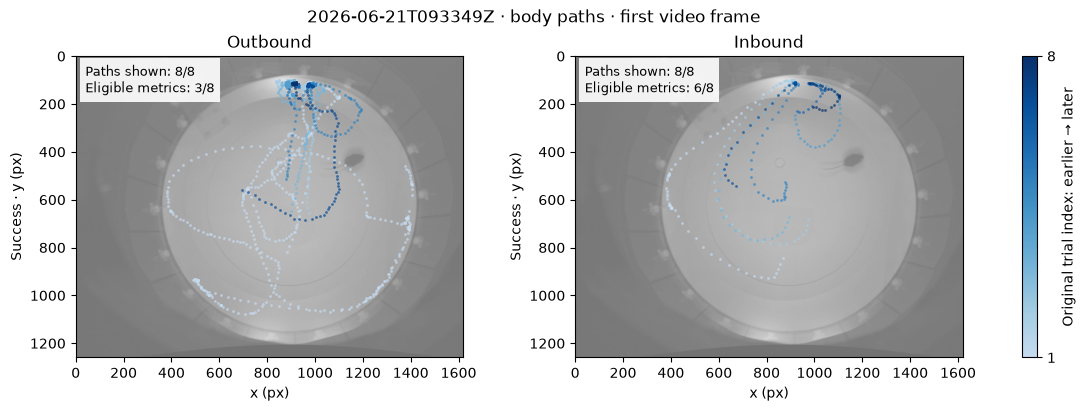

In [7]:
# ===============================================================================
# 5| Prepare and Plot Each Recording with Its Own Calibration and First Frame
# ===============================================================================


def build_trajectory_figures(
    sessions, 
    streams, 
    selected_trials, 
    *, 
    individual, 
    tracking_keypoint,
    confidence_threshold, 
    max_gap_frames, 
    smoothing_window,
    max_sample_interval_s, 
    space_unit, 
    pixels_per_cm_by_session,
    group_by="outcome", 
    arena_range=None, 
    cmap="Blues", 
    marker_size=4,
    path_alpha=0.70, 
    background_alpha=0.55,
):
    """Measure selected paths and return spatial figures for their own recordings.

    Parameters
    ----------
    sessions : mapping[str, SessionRef]
        Stable recording keys mapped to references returned by DataStructure.select.
        Each reference supplies the path used to read that recording's first frame.
    streams : mapping[str, object]
        Loaded streams with aligned 'dlc:position' and 'dlc:confidence' arrays.
        Both arrays carry recording identity along their acquired-seconds clock.
    selected_trials : pandas.DataFrame
        Already selected trial rows, with the columns required by measure_trial_paths.
        Session identities determine which recording's pose each trial receives.
    individual : str
        Individual identity assigned during conversion from native DLC arrays.
    tracking_keypoint : str
        One fixed pose keypoint, used consistently for all measured paths.
    confidence_threshold : float | None
        Minimum retained tracking confidence; None disables confidence filtering.
    max_gap_frames : int | None
        Optional maximum missing gap in samples for pose interpolation; None
        preserves gaps. Processing is applied to a complete recording first.
    smoothing_window : int | None
        Optional median-filter width in recorded samples; None preserves positions.
    max_sample_interval_s : float | None
        Optional positive maximum acquired interval in seconds between path
        samples. Larger gaps exclude metrics; None disables this extra check.
    space_unit : str
        'px' retains pixels; 'cm' converts both tracked positions and frame edges
        using the same measured calibration for each recording.
    pixels_per_cm_by_session : mapping[str, float]
        Finite positive pixels/cm calibration per recording key, required for 'cm'.
        Ignored in pixel mode; missing calibrations never receive an invented value.
    group_by : str
        Path-grid rows: 'outcome', 'session' or 'trial'. Selection is unchanged.
    arena_range : tuple[tuple[float, float], tuple[float, float]] | None
        Optional ((xmin, xmax), (ymin, ymax)) crop in space_unit; None shows the
        complete first video frame, aligned to integer image pixel centres.
    cmap : str
        Matplotlib colour map for original chronological trial indices.
    marker_size : float
        Positive trajectory-marker area in points squared.
    path_alpha : float
        Trajectory-sample opacity in (0, 1].
    background_alpha : float
        First-video-frame opacity in [0, 1].

    Returns
    -------
    metrics : pandas.DataFrame
        Selected phase measurements and exclusions, with original recording/trial
        identities and space_unit. Empty, with expected columns, if all recordings
        lack either selected trials or aligned pose.
    figures : dict[str, dict]
        One entry per plotted recording containing figure (Matplotlib Figure),
        axes (two-dimensional array), plot_report (phase rows with path_shown),
        and background_video_path (Path identifying the source video).
    skipped : pandas.DataFrame
        Recording keys and reasons for selected recordings lacking aligned pose.
        Recordings with no selected trials are omitted from all three outputs.

    Notes
    -----
    The function returns figures and reports without calling show or display.
    It reads real first frames and never substitutes an unrelated or blank image.
    Only scalar metric rows are combined; recording clocks and pose stay separate.
    """
    # === 1| Validate Units and Identify Recordings with Aligned Pose =============
    if space_unit not in ("px", "cm"):
        raise ValueError("space_unit must be 'px' or 'cm'.")
    metric_tables, figures, skipped = [], {}, []
    pose_sessions = []
    if "dlc:position" in streams and "dlc:confidence" in streams:
        pose_sessions = pd.unique(streams["dlc:position"].session.values).tolist()

    for session_id, session in sessions.items():
        # === 2.1| Select Each Recording Before Accessing Its Own Pose Clock ======
        session_trials = slice_stream(selected_trials, selectors={"session": session_id})
        if session_trials.empty:
            continue
        if session_id not in pose_sessions:
            skipped.append({"session": session_id, "reason": "No aligned pose was loaded"})
            continue

        # === 2.2| Process Complete Pose Before Splitting into Trial Phases =======
        position = slice_stream(streams["dlc:position"], selectors={"session": session_id})
        confidence = slice_stream(streams["dlc:confidence"], selectors={"session": session_id})
        raw_pose = pose_to_movement(position, confidence, individual=individual)
        pose = prepare_pose(
            raw_pose, confidence_threshold=confidence_threshold,
            max_gap_frames=max_gap_frames, smoothing_window=smoothing_window,
        )
        point = pose.position.sel(individual=individual, keypoint=tracking_keypoint, drop=True)

        # === 2.3| Apply the Same Calibration to Positions and First-Frame Edges ==
        spatial_scale = 1.0
        if space_unit == "cm":
            pixels_per_cm = pixels_per_cm_by_session.get(session_id)
            if pixels_per_cm is None or not np.isfinite(pixels_per_cm) or pixels_per_cm <= 0:
                raise ValueError(f"Supply a finite positive pixels/cm calibration for {session_id!r}.")
            spatial_scale = 1.0 / pixels_per_cm
        point = point * spatial_scale
        point.attrs["space_unit"] = space_unit
        frame, video_path = read_session_video_frame(session.path)  # The shared reader explicitly decodes frame zero.
        height, width = frame.shape[:2]
        frame_extent = tuple(edge * spatial_scale for edge in (-0.5, width - 0.5, height - 0.5, -0.5))

        # === 2.4| Retain Every Exclusion and Draw Paths over This Exact Frame =====
        session_metrics, phase_paths = measure_trial_paths(
            point, session_trials, max_sample_interval_s=max_sample_interval_s,
        )
        session_metrics["space_unit"] = space_unit
        metric_tables.append(session_metrics)
        figure, axes, plot_report = plot_session_path_grid(
            phase_paths, session_metrics, frame,
            frame_extent=frame_extent, space_unit=space_unit,
            group_by=group_by, arena_range=arena_range,
            cmap=cmap, marker_size=marker_size, path_alpha=path_alpha,
            background_alpha=background_alpha,
            panel_size=(5.5, 4), title=f"{session_id} · {tracking_keypoint} paths · first video frame",
        )
        figures[session_id] = {
            "figure": figure, "axes": axes, "plot_report": plot_report,
            "background_video_path": video_path,
        }

    # === 3| Return Combined Scalar Reports with Recording Identity Preserved =====
    if metric_tables:
        metrics = pd.concat(metric_tables, ignore_index=True)
    else:
        metrics = pd.DataFrame(columns=[
            "session", "trial_index", "phase", "outcome",
            "start_inclusive", "end_inclusive", "n_samples", "n_valid_samples",
            "path_length", "mean_deviation", "status", "space_unit",
        ])
    return metrics, figures, pd.DataFrame(skipped, columns=["session", "reason"])


# === 4| Run with Explicit Settings, then Inspect Figures and Exclusion Reports ===
metrics, trajectory_figures, skipped_recordings = build_trajectory_figures(
    sessions, 
    streams, 
    selected_trials,
    individual=INDIVIDUAL, 
    tracking_keypoint=TRACKING_KEYPOINT,
    confidence_threshold=CONFIDENCE_THRESHOLD, 
    max_gap_frames=MAX_GAP_FRAMES,
    smoothing_window=SMOOTHING_WINDOW, 
    max_sample_interval_s=MAX_SAMPLE_INTERVAL_S,
    space_unit=SPATIAL_UNIT,
    pixels_per_cm_by_session=PIXELS_PER_CM_BY_SESSION,
    group_by=PATH_GROUP_BY, 
    arena_range=ARENA_RANGE,
    cmap=PATH_CMAP, 
    marker_size=PATH_POINT_SIZE,
    path_alpha=PATH_ALPHA, 
    background_alpha=BACKGROUND_ALPHA,
)


display(metrics, skipped_recordings)
for recording_id, result in trajectory_figures.items():
    print(f"{recording_id}: first frame of {result['background_video_path']}")
    display(result["plot_report"])
plt.show()


,session,trial_index,outcome,outbound_path_length,outbound_status,inbound_mean_deviation,inbound_status
0,2026-06-21T093349Z,1,Success,NaN,unfilled tracking gaps,NaN,unfilled tracking gaps
1,2026-06-21T093349Z,2,Success,NaN,unfilled tracking gaps,160.429861,ok
2,2026-06-21T093349Z,3,Success,NaN,unfilled tracking gaps,131.671985,ok
3,2026-06-21T093349Z,4,Success,NaN,unfilled tracking gaps,NaN,unfilled tracking gaps
4,2026-06-21T093349Z,5,Success,1300.540054,ok,51.553620,ok
5,2026-06-21T093349Z,6,Success,287.108208,ok,41.368891,ok
6,2026-06-21T093349Z,7,Success,1186.207021,ok,30.961853,ok
7,2026-06-21T093349Z,8,Success,NaN,unfilled tracking gaps,61.105529,ok


Paired comparison: 3 eligible / 8 selected trials


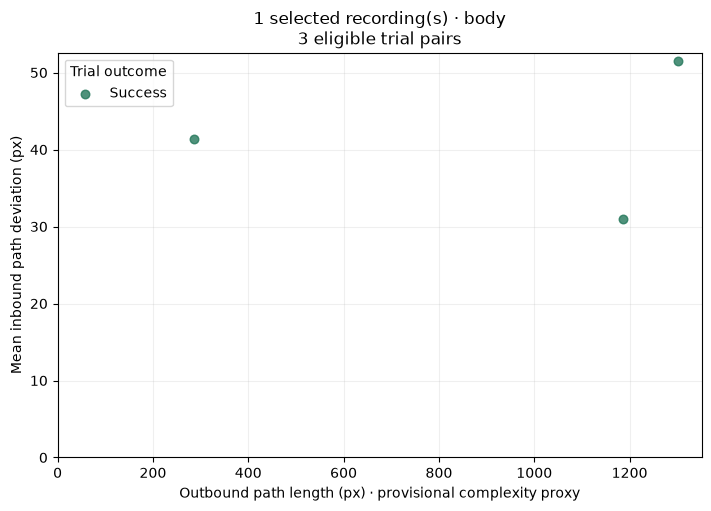

In [8]:
# ===============================================================================
# 6| Pair Outbound and Inbound by Recording and Original Trial Index
# ===============================================================================

# === 1| Give the Two Phase Measurements Explicit Comparison-Column Names =========

outbound = metrics.loc[metrics.phase.eq("outbound"), ["session", "trial_index", "outcome", "path_length", "status"]]
outbound = outbound.rename(columns={"path_length": "outbound_path_length", "status": "outbound_status"})
inbound = metrics.loc[metrics.phase.eq("inbound"), ["session", "trial_index", "mean_deviation", "status"]]
inbound = inbound.rename(columns={"mean_deviation": "inbound_mean_deviation", "status": "inbound_status"})

# === 2| Join Only Matching Identities and Keep the Exclusion Reasons Visible =====

paired_metrics = outbound.merge(
    inbound, on=["session", "trial_index"],
    how="outer", validate="one_to_one",                                # Equal trial numbers in different recordings must never be paired together.
)
valid_pairs = paired_metrics.loc[
    paired_metrics.outbound_status.eq("ok") & paired_metrics.inbound_status.eq("ok")
].copy()                                                              # Eligibility selection occurs here, before the plotting function receives data.
display(paired_metrics)
print(f"Paired comparison: {len(valid_pairs)} eligible / {len(paired_metrics)} selected trials")

# === 3| Draw Exactly the Eligible Pairs with Display Parameters Kept Explicit =====

comparison_fig, comparison_ax = plot_length_vs_deviation(
    valid_pairs, space_unit=SPATIAL_UNIT, outcome_colors=OUTCOME_COLORS,
    point_size=38, alpha=0.8, figsize=(7, 5),
    title=f"{metrics.session.nunique()} selected recording(s) · {TRACKING_KEYPOINT}",
)
plt.show()

Rerun the recording loop after changing trial selection, processing or calibration. The measurement and plotting functions can also be called directly on already loaded data.
